## Read Dataset

In [1]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

# Fetch the MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
assert mnist is not None, "Data and target are not found"

# Only use 20% of data
num_of_samples = mnist.data.shape[0] // 5

X_original = mnist.data[:num_of_samples]
y_original = mnist.target[:num_of_samples]

# Rescale to [0, 1.0]
X_original = X_original / 255
X_original = X_original.reshape(-1, 28, 28)


X_original.shape, y_original.shape

((14000, 28, 28), (14000,))

## Visualize data

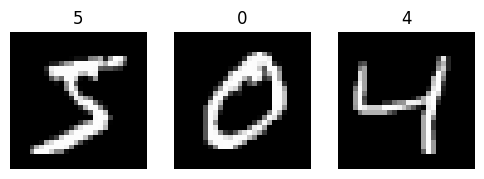

In [2]:
plt.figure(figsize=(6, 2))

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(X_original[i], cmap='gray')
    plt.title(y_original[i])
    plt.axis(False)

plt.show()

## Prepare train loader

In [3]:
%reload_ext autoreload
from src import get_data_loader

loader = get_data_loader(train_data=X_original, batch_size=64)

len(loader)

219

# 2. Training model

In [ ]:
from src.autoencoder import CNNAutoencoder
from src.loss import PersistenceLoss, PermutationPersistenceLoss
from src.models import ModelState
from torch.nn import MSELoss
import torch
from torch.optim import Adam

# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = "cpu"

torch.manual_seed(42)
learning_rate = 1e-3

model = CNNAutoencoder().to(device)
optimizer = Adam(model.parameters(), lr=learning_rate)

mse_loss = MSELoss()
persistence_loss = PersistenceLoss()
permutation_persistence_loss = PermutationPersistenceLoss()

model_state = ModelState(
    model, 
    model_name="TopoAE_v0_3-7_full", 
    loss_description=["MSELoss", "TopoLoss"], 
    learning_rate=learning_rate, 
    ph_loss_scale=10,
    seed=42, 
    optimizer="Adam"
)

model_state.log()

--------------------------------------------------
model: CNNAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(7, 7), stride=(1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(7, 7), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)
model_name: TopoAE_v0_3-7_full
args: {'learning_rate': 0.001, 'ph_loss_scale': 10, 'seed': 42, 'optimizer': 'Adam'}
loss_history: []
loss_description: ['MSELoss', 'TopoLoss']
--------------------------------------------------


In [ ]:
from src.models import ModelState
from tqdm import tqdm

device = "cpu"

def training_model(model_state: ModelState, loader, num_epochs=10):
    model_state.model.train()
    ph_loss_scale = model_state.args.get("ph_loss_scale", 0)

    # Create tqdm object for epochs
    epoch_pbar = tqdm(range(num_epochs), desc="Epochs")
    
    for epoch in epoch_pbar:
        p_topo_loss = 0
        p_mse_loss = 0

        for batch in loader:
            batch = batch.unsqueeze(1)
            optimizer.zero_grad()
            
            # Forward pass
            encode = model_state.model.encode(batch)
            reconstructed = model_state.model.decode(encode)
            
            # Compute losses
            loss_mse = mse_loss(batch, reconstructed)
            loss_topo = persistence_loss(batch, encode) * ph_loss_scale
            loss = loss_mse + loss_topo

            p_topo_loss += loss_topo.item()
            p_mse_loss += loss_mse.item()
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
    
        # Average losses
        avg_topo_loss = p_topo_loss/len(loader)
        avg_mse_loss = p_mse_loss/len(loader)
        
        model_state.loss_record((avg_mse_loss, avg_topo_loss))
        
        # Update tqdm description with current losses
        epoch_pbar.set_description(f"Epoch {epoch+1}/{num_epochs} | Topo: {avg_topo_loss:.4f} | MSE: {avg_mse_loss:.4f}")

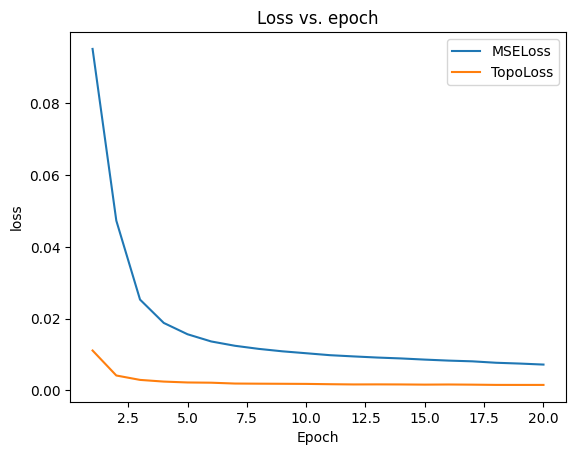

In [ ]:
model_state = ModelState(model=CNNAutoencoder())
model_state.load_model(model_name="TopoAE_v0_3-7_full")

model_state.visualize_loss()

# 3. Train AutoEncoder Model

In [14]:
from src import ModelState
from tqdm import tqdm

def ae_training_model(model_state: ModelState, loader, num_epochs=10):
    model_state.model.train()

    # Create tqdm object for epochs
    epoch_pbar = tqdm(range(num_epochs), desc="Epochs")
    
    for epoch in epoch_pbar:
        p_mse_loss = 0

        for batch in loader:
            batch = batch.unsqueeze(1)
            optimizer.zero_grad()
            
            # Forward pass
            encode = model_state.model.encode(batch)
            reconstructed = model_state.model.decode(encode)
            
            # Compute losses
            loss_mse = mse_loss(batch, reconstructed)
            p_mse_loss += loss_mse.item()
            
            # Backward pass and optimization
            loss_mse.backward()
            optimizer.step()
    
        # Average losses
        avg_mse_loss = p_mse_loss/len(loader)
        model_state.loss_record([avg_mse_loss])
        epoch_pbar.set_postfix({"MSE": avg_mse_loss})
        
        # Update tqdm description with current loss
        # epoch_pbar.set_description(f"Epoch {epoch+1}/{num_epochs} | MSE: {avg_mse_loss:.4f}")

In [11]:
torch.manual_seed(42)
model = CNNAutoencoder().to(device)
optimizer = Adam(model.parameters(), lr=learning_rate)
mse_loss = MSELoss()

model_state = ModelState(
    model, 
    model_name="AE_v0_12-7", 
    loss_description=["MSELoss"], 
    learning_rate=learning_rate,
    seed=42, 
    optimizer="Adam"
)

model_state.log()

--------------------------------------------------
model: CNNAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(7, 7), stride=(1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(7, 7), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)
model_name: AE_v0_12-7
args: {'learning_rate': 0.001, 'seed': 42, 'optimizer': 'Adam'}
loss_history: []
loss_description: ['MSELoss']
--------------------------------------------------


Epochs: 100%|██████████| 20/20 [01:07<00:00,  3.37s/it, MSE=0.00235]

Model saved to /Users/trantrunghcmut/Documents/hcmut/topological data analysis/TopoAE Code/models/AE_v0_12-7


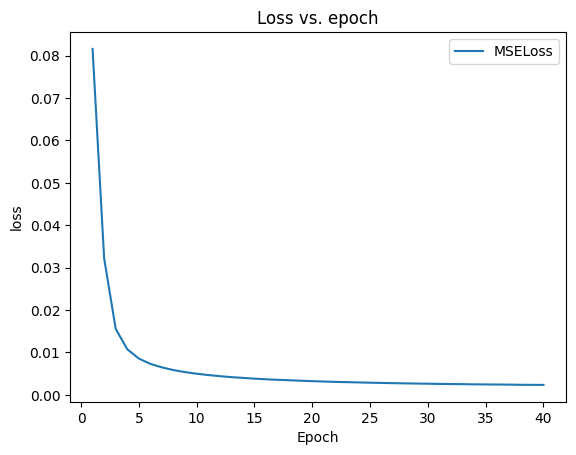

In [15]:
ae_training_model(model_state, loader, num_epochs=20)

model_state.save_model()
model_state.visualize_loss()